<a href="https://colab.research.google.com/github/MPCCoder/Data-Science-e-Modelos-Preditivos/blob/main/Data_Science_e_Modelos_Preditivos_Lab3_Live.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bem-vindos ao Laboratório de Data Science! 🚀
Nesta segunda parte da sessão, vamos "sujar as mãos" com dados. Vamos utilizar o **Google Colab**, que nos permite executar código **Python 3.11**
 diretamente no browser.

Para executar uma célula de código, basta clicar no botão de "Play" (▶) à esquerda ou usar o atalho `Shift + Enter`.


In [2]:
# O nosso primeiro código em Python
mensagem = "Olá, equipa! O ambiente Colab está a funcionar perfeitamente."
print(mensagem)

# Um pequeno teste com a nossa realidade industrial
máquinas = 15
sensores_por_maquina = 4
total_sensores = máquinas * sensores_por_maquina

print(f"Temos {total_sensores} sensores a gerar telemetria na fábrica.")

Olá, equipa! O ambiente Colab está a funcionar perfeitamente.
Temos 60 sensores a gerar telemetria na fábrica.


##1. Ligar a nossa "Base de Dados" (Google Drive) 📁
Na prática, os dados vêm de extrações de Business Intelligence ou diretamente das máquinas industriais. Para o Colab conseguir ler os nossos ficheiros (como os CSVs que vamos usar no projeto), precisamos de lhe dar permissão para aceder ao nosso Google Drive.

> Nota: Ao correr a célula abaixo, aparecerá a mensagem "Permit this notebook to access your Google Drive files?". Devem clicar em "Connect to Google Drive" e autorizar o acesso com a vossa conta.


In [3]:
# @title
# Permitir que o Colab veja os ficheiros do Google Drive [1]
#descomentar daqui para baixo
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)
#print("Google Drive ligado com sucesso! Já podemos extrair dados.")



> O exemplo acima é o mais prático para carregarmos os nossos dados gravados no Google Drive, mas para facilidade da formação vamos usar nesta primeira sessão o Github exemplificado mais abaixo. O código a utilizar para ler do drive é:

```
# 1. Definir o caminho para o ficheiro no Google Drive (ajustar conforme necessário)
caminho_ficheiro = '/content/drive/MyDrive/datamining.csv' # Exemplo baseado no material prático [1]

# 2. Ler o ficheiro para a variável 'df' (Dataframe)
try:
    df = pd.read_csv(caminho_ficheiro)
    print("Ficheiro carregado com sucesso!\n")
    
    # 3. Mostrar as primeiras linhas da nossa tabela para verificar os dados
    display(df.head())
    
except FileNotFoundError:
    print("Erro: Ficheiro não encontrado. Verifiquem o caminho do vosso Drive!")

```





##2. O Nosso "Canivete Suíço": Numpy e Pandas 🛠️

Para não termos de programar tudo do zero, a Ciência de Dados vive de bibliotecas prontas a usar.

As duas fundamentais que iniciam o nosso programa são:
* NumPy: O motor matemático para operações rápidas.
* Pandas: A biblioteca principal para manipulação de dados, que permite ler tabelas (DataFrames) de forma muito intuitiva.

In [4]:
# Importação das bibliotecas (é padrão usar as abreviaturas 'np' e 'pd')
import numpy as np
import pandas as pd

print("Pandas e Numpy carregados! Estamos prontos para a Análise de Dados.")

Pandas e Numpy carregados! Estamos prontos para a Análise de Dados.


##3. O Primeiro Contacto com os Dados Reais 📊
Agora vamos ler o nosso primeiro ficheiro (no formato CSV).

O Pandas transforma este ficheiro num DataFrame (uma tabela nativa do Python).

In [5]:
csv_github_url = 'https://raw.githubusercontent.com/MPCCoder/Data-Science-e-Modelos-Preditivos/refs/heads/main/datamining.csv'
df = pd.read_csv(csv_github_url)

print("CSV carregado com sucesso do GitHub!")
df.head(20)

CSV carregado com sucesso do GitHub!


,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,1961,90782.0,33,66,1402,37,5,44,10,3,0.0,19,M,Graduation,Together,Take my money!!
1,1951,113023.0,32,6,1537,55,1,38,4,2,0.0,9,F,PhD,Divorced,Take my money!!
2,2005,28344.0,11,69,44,32,19,24,1,24,1.0,59,M,Graduation,Married,Kind of OK
3,1970,93571.0,26,10,888,60,10,19,6,5,1.0,35,F,Master,NaN,OK nice!
4,1970,91852.0,31,26,1138,59,5,28,4,4,1.0,34,F,Graduation,Together,Take my money!!
5,1997,22386.0,14,65,56,47,2,48,2,1,1.0,67,M,PhD,Single,OK nice!
6,1984,69485.0,18,73,345,71,7,13,1,8,1.0,46,M,Graduation,Together,OK nice!
7,1975,68602.0,5,44,41,84,1,12,2,0,1.0,37,M,Graduation,Together,Horrible
8,1955,109499.0,30,75,1401,38,9,35,9,9,0.0,17,M,Graduation,Divorced,OK nice!
9,2009,23846.0,8,153,19,18,55,17,10,1,1.0,39,F,1st Cycle,Together,Meh...


## 4. O Primeiro Raio-X aos Dados (Introdução à EDA) 📊
Para os perfis mais técnicos, queremos saber os tipos de dados que a máquina importou (inteiros, decimais, texto). Para os perfis de negócio e operações, queremos ver resumos estatísticos rápidos para detetar anomalias ou falhas.
Vamos usar dois comandos mágicos do Pandas:
*  **df.info()**: Mostra-nos as colunas, os tipos de dados e se há dados em falta (Missing Values).
*  **df.describe()**: Calcula automaticamente estatísticas descritivas como a média, mínimo, máximo e desvio padrão para todas as colunas numéricas.

In [6]:
print("--- INFORMAÇÃO TÉCNICA DO DATASET ---")
# O info() ajuda-nos a ver se temos valores nulos que precisem de limpeza futura
df.info()

print("\n\n--- ESTATÍSTICAS DESCRITIVAS ---")
# O describe() faz a matemática básica por nós em segundos
display(df.describe())


--- INFORMAÇÃO TÉCNICA DO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8998 entries, 0 to 8997
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               8998 non-null   int64  
 1   income            8952 non-null   float64
 2   frq               8998 non-null   int64  
 3   rcn               8998 non-null   int64  
 4   mnt               8998 non-null   int64  
 5   clothes           8998 non-null   int64  
 6   kitchen           8998 non-null   int64  
 7   small_appliances  8998 non-null   int64  
 8   toys              8998 non-null   int64  
 9   house_keeping     8998 non-null   int64  
 10  dependents        8716 non-null   float64
 11  per_net_purchase  8998 non-null   int64  
 12  gender            8998 non-null   object 
 13  education         8951 non-null   object 
 14  status            8821 non-null   object 
 15  description       8998 non-null   object 
dtypes: f

,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase
count,8998.000000,8952.000000,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000,8716.000000,8998.000000
mean,1981.059680,69963.550827,19.848077,62.469771,622.162814,50.446655,7.039675,28.524116,7.036897,6.929984,0.707205,42.428984
std,17.296552,27591.556226,10.903435,69.761802,646.768205,23.422249,7.848139,12.586437,7.924422,7.882655,0.455071,18.495742
min,1951.000000,10000.000000,3.000000,0.000000,6.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,4.000000
25%,1966.000000,47741.000000,10.000000,26.000000,63.000000,33.000000,2.000000,19.000000,2.000000,2.000000,0.000000,28.000000
50%,1981.000000,70030.500000,17.000000,53.000000,383.000000,51.000000,4.000000,28.000000,4.000000,4.000000,1.000000,45.000000
75%,1996.000000,92218.000000,28.000000,79.000000,1076.000000,69.000000,10.000000,37.000000,10.000000,9.000000,1.000000,57.000000
max,2011.000000,140628.000000,59.000000,549.000000,3052.000000,99.000000,75.000000,74.000000,62.000000,77.000000,1.000000,88.000000


#Sessão 2: Análise Exploratória de Dados (EDA) e Visualização 📊
Agora que já temos os nossos dados carregados num DataFrame chamado `df`, vamos dar início à nossa EDA. O objetivo da EDA não é criar gráficos bonitos, mas sim compreender o comportamento dos dados, detetar anomalias (erros) e procurar correlações que nos ajudem a prever o futuro.
Para isso, vamos usar duas bibliotecas clássicas de Python:
* **Matplotlib**: A base de toda a visualização em Python.
* **Seaborn**: Uma biblioteca construída sobre o Matplotlib que cria gráficos estatísticos complexos com apenas uma linha de código.

In [7]:
# Importar as bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para os nossos gráficos ("Less is More")
sns.set_theme(style="whitegrid")
print("Bibliotecas de visualização carregadas com sucesso!")

Bibliotecas de visualização carregadas com sucesso!


##Compreender o Negócio e os dados
Eeste dataset de Data Mining consiste num perfil detalhado de clientes, agregando atributos fundamentais para a análise exploratória (EDA) e futura modelação preditiva. As variáveis que compõem este dataframe incluem:

* age - ano de nascimento
* income - rendimento
* frq - frequency: n.º de compras
* rcn - recency: n.º de dias decorridos desde a útima compra
* mnt - monetary: valor gasto
* clothes - % de valor gasto em roupa
* kitchen - % de valor gasto em cozinha
* small_appliances - % de valor gasto em pequenos eletrodomêticos
* toys - % de valor gasto em brinkedos
* house_keeping - % de valor gasto em produtos de limpeza
* dependents - tem dependentes?
* per_net_purchase - % de compras online
* gender - género
* education - nível de instrução
* status - estado civil
* description - grupo de cliente




##Distribuições e Histogramas 📈
O Histograma mostra-nos a distribuição de frequências de uma variável, ou seja, onde é que a maioria dos nossos dados se concentra
. Vamos analisar a variável AGE (Idade) para perceber se a nossa base de dados é maioritariamente jovem ou mais envelhecida.

In [8]:
current_year = 2026
df['current_age_2026'] = current_year - df['age']
display(df.head())

,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description,current_age_2026
0,1961,90782.0,33,66,1402,37,5,44,10,3,0.0,19,M,Graduation,Together,Take my money!!,65
1,1951,113023.0,32,6,1537,55,1,38,4,2,0.0,9,F,PhD,Divorced,Take my money!!,75
2,2005,28344.0,11,69,44,32,19,24,1,24,1.0,59,M,Graduation,Married,Kind of OK,21
3,1970,93571.0,26,10,888,60,10,19,6,5,1.0,35,F,Master,NaN,OK nice!,56
4,1970,91852.0,31,26,1138,59,5,28,4,4,1.0,34,F,Graduation,Together,Take my money!!,56


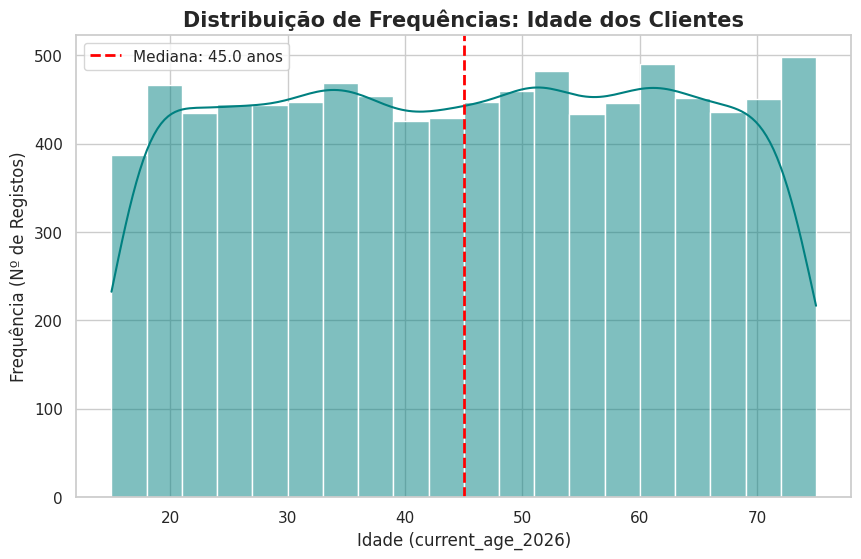

In [9]:
plt.figure(figsize=(10, 6))

# Criar um histograma com a linha de tendência (KDE - Kernel Density Estimate)
sns.histplot(data=df, x='current_age_2026', bins=20, kde=True, color='teal')

# Adicionar uma linha vertical para a Mediana
mediana_idade = df['current_age_2026'].median()
plt.axvline(mediana_idade, color='red', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_idade} anos')

plt.title('Distribuição de Frequências: Idade dos Clientes', fontsize=15, fontweight='bold')
plt.xlabel('Idade (current_age_2026)', fontsize=12)
plt.ylabel('Frequência (Nº de Registos)', fontsize=12)
plt.legend()

plt.show()

## Variáveis Categóricas
Para visualizar a distribuição de uma coluna categórica como 'status', um **gráfico de barras (bar plot)** é mais apropriado do que um histograma. Um histograma é usado para dados numéricos contínuos, enquanto um gráfico de barras mostra a frequência ou contagem de cada categoria. Vamos criar um gráfico de barras para a coluna 'status'.


--- Análise da Coluna: 'gender' ---
Valores Únicos: ['M' 'F']


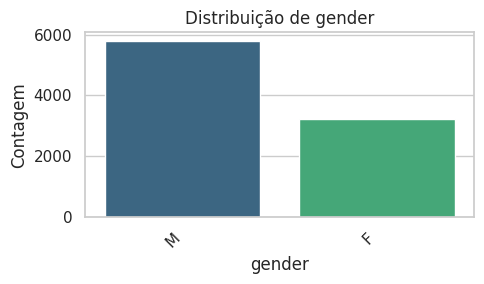

,gender,Count
0,M,5784
1,F,3214



--- Análise da Coluna: 'education' ---
Valores Únicos: ['Graduation' 'PhD' 'Master' '1st Cycle' '2nd Cycle' 'OldSchool' nan]


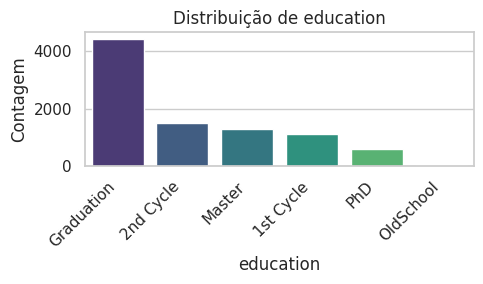

,education,Count
0,Graduation,4429
1,2nd Cycle,1496
2,Master,1303
3,1st Cycle,1104
4,PhD,593
5,OldSchool,26



--- Análise da Coluna: 'status' ---
Valores Únicos: ['Together' 'Divorced' 'Married' nan 'Single' 'Widow' 'Whatever']


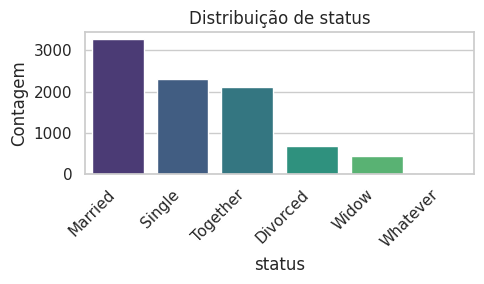

,status,Count
0,Married,3273
1,Single,2293
2,Together,2118
3,Divorced,677
4,Widow,445
5,Whatever,15



--- Análise da Coluna: 'description' ---
Valores Únicos: ['Take my money!!' 'Kind of OK' 'OK nice!' 'Horrible' 'Meh...']


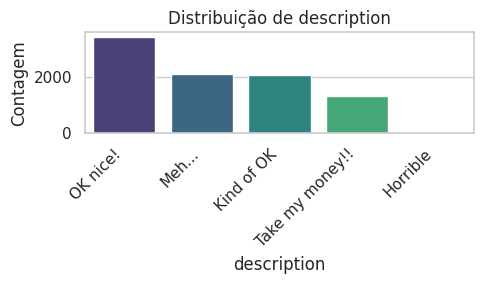

,description,Count
0,OK nice!,3434
1,Meh...,2107
2,Kind of OK,2090
3,Take my money!!,1326
4,Horrible,41


In [10]:
#construção da lista com as variáveis categóricas
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    print(f"\n--- Análise da Coluna: '{col}' ---")
    print("Valores Únicos:", df[col].unique())

    # Contar a frequência de cada valor
    col_counts = df[col].value_counts().reset_index()
    col_counts.columns = [col, 'Count']

    # Criar o gráfico de barras
    plt.figure(figsize=(5, 3))
    sns.barplot(x=col, y='Count', data=col_counts, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Contagem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    display(col_counts)

##O Raio-X aos Outliers: O Boxplot 📦
A média muitas vezes esconde a verdade devido ao "Efeito de Alavanca" de valores extremos. Para isolarmos os verdadeiros **Outliers** (anomalias), usamos o **Boxplot**

O Boxplot desenha uma caixa que contém os 50% centrais dos dados (o Interquartile Range - IQR). Qualquer ponto desenhado fora dos "bigodes" laterais (`Q1 - 1.5 * IQR ou Q3 + 1.5 * IQR`) é estatisticamente considerado um Outlier
Vamos analisar o Rendimento (INCOME).

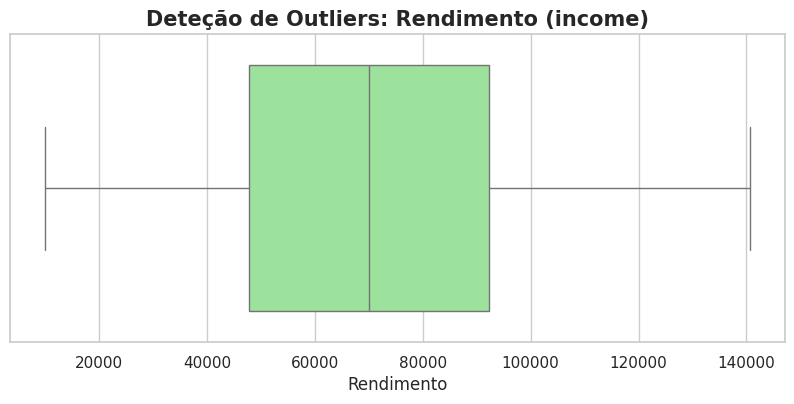

-> Conclusão Rápida: O rendimento máximo registado na base de dados é 140628.0.
-> Não aparenta haver outliers no income.


In [11]:
plt.figure(figsize=(10, 4))

# Desenhar o Boxplot horizontal para a variável Rendimento
sns.boxplot(data=df, x='income', color='lightgreen')

plt.title('Deteção de Outliers: Rendimento (income)', fontsize=15, fontweight='bold')
plt.xlabel('Rendimento', fontsize=12)

plt.show()

# Tirar conclusões extraindo os valores extremos
maximo_rendimento = df['income'].max()
print(f"-> Conclusão Rápida: O rendimento máximo registado na base de dados é {maximo_rendimento}.")
print("-> Não aparenta haver outliers no income.")

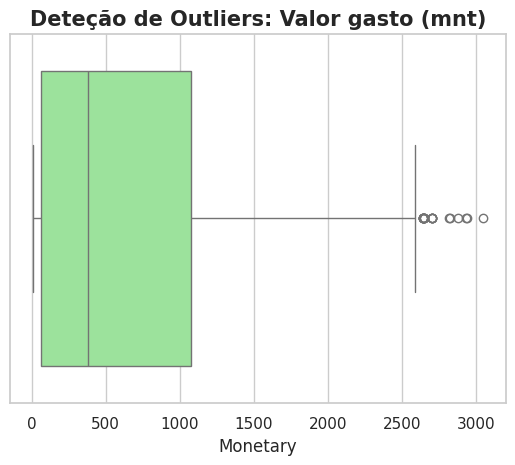

-> Conclusão Rápida: O valor gasto máximo é 3052.
-> Existem valores a considerar outliers.


In [12]:
# Desenhar o Boxplot horizontal para a variável mnt (Monetary - Total Gasto)
sns.boxplot(data=df, x='mnt', color='lightgreen')

plt.title('Deteção de Outliers: Valor gasto (mnt)', fontsize=15, fontweight='bold')
plt.xlabel('Monetary', fontsize=12)

plt.show()

# Tirar conclusões extraindo os valores extremos
maximo_mnt = df['mnt'].max()
print(f"-> Conclusão Rápida: O valor gasto máximo é {maximo_mnt}.")
print("-> Existem valores a considerar outliers.")

##Matriz de Correlação e Redundância 🔥
Para evitar a "Maldição da Dimensionalidade" e a Multicolinearidade, precisamos de saber se temos variáveis preditoras que contam exatamente a mesma história.

A **Correlação de Pearson** mede o grau de associação linear entre duas variáveis (varia entre -1 e 1).

Um valor muito próximo de 1 ou -1 significa que as variáveis são altamente redundantes. Vamos usar um Mapa de Calor (Correlation Heatmap) para expor estas relações!

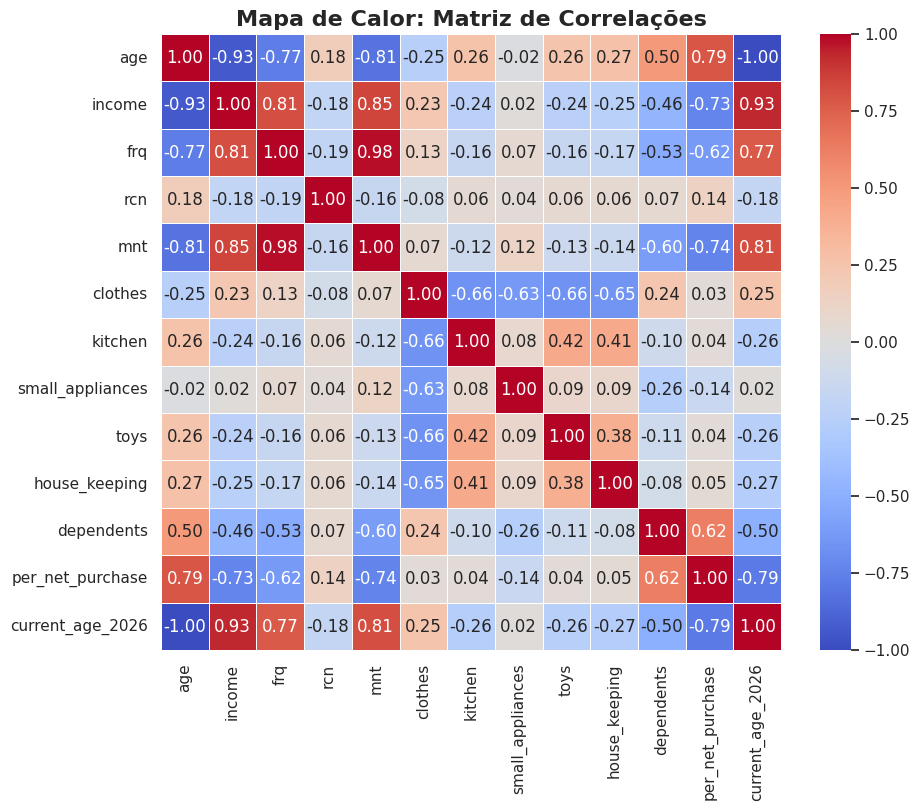

In [13]:
plt.figure(figsize=(10, 8))

# 1. Calcular a correlação de Pearson apenas para as colunas numéricas
matriz_correlacao = df.corr(numeric_only=True)

# 2. Desenhar o Mapa de Calor (Heatmap)
# annot=True coloca os valores dentro dos quadrados, cmap dita a paleta de cores
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Mapa de Calor: Matriz de Correlações', fontsize=16, fontweight='bold')
plt.show()

# Sessão 3: Preparação de Dados para Modelação (Data Prep) 🛠️
Nesta terceira sessão, vamos preparar os nossos dados para os algoritmos de *Machine Learning*. A capacidade preditiva de um modelo depende inteiramente da qualidade dos dados que lhe fornecemos (o famoso princípio de "Garbage in, Garbage out").

Vamos cobrir as etapas essenciais de transformação, limpeza e criação de novas variáveis (*Feature Engineering*).


## Inspeção de Valores Ausentes (*Missing Values*) 🔎
Antes de avançarmos, precisamos de mapear exatamente onde faltam dados.
Vamos usar a função `.isnull().sum()` para contar a quantidade de nulos em cada coluna do nosso *DataFrame*.

In [14]:
df.isnull().sum()[df.isnull().sum()>0]

,0
income,46
dependents,282
education,47
status,177


In [15]:
num_rows_with_null = df.isnull().any(axis=1).sum()
print(f"Número de linhas com missing values: {num_rows_with_null}")

dataframe_length = len(df)
print(f"Comprimento do df: {dataframe_length}")

percentage_missing = (num_rows_with_null / dataframe_length)

print(f"Percentagem de linhas a excluir (com algum valor a null): {percentage_missing:.2%}")

Número de linhas com missing values: 542
Comprimento do df: 8998
Percentagem de linhas a excluir (com algum valor a null): 6.02%


## Tratamento de *Missing Values* 🧽
Identificámos valores em falta nas colunas `income`, `dependents`, `status` e `education`. A nossa estratégia será adaptada ao tipo de dado:
*   **Numéricas (`income`, `dependents`):** Vamos preencher o rendimento com a mediana (menos sensível a outliers) e assumir que a ausência de `dependents` significa 0.
*   **Categóricas (`status`, `education`):** Vamos preencher os nulos com a moda (o valor mais frequente) ou categorizá-los.

In [16]:
mediana_income = df['income'].median()

df['income'] = df['income'].fillna(mediana_income)

display(df['dependents'].value_counts())

df['dependents'] = df['dependents'].fillna(0)
display(df['dependents'].unique())
df['dependents'].value_counts()

,count
dependents,
1.0,6164
0.0,2552


array([0., 1.])

,count
dependents,
1.0,6164
0.0,2834


In [17]:
df.isnull().sum()[df.isnull().sum()>0]

,0
education,47
status,177


In [18]:
num_rows_with_null = df.isnull().any(axis=1).sum()
print(f"Número de linhas com missing values: {num_rows_with_null}")

dataframe_length = len(df)
print(f"Comprimento do df: {dataframe_length}")

percentage_missing = (num_rows_with_null / dataframe_length)

print(f"Percentagem de linhas a excluir (com algum valor a null): {percentage_missing:.2%}")

Número de linhas com missing values: 223
Comprimento do df: 8998
Percentagem de linhas a excluir (com algum valor a null): 2.48%



--- Análise da Coluna: 'education' ---
Valores Únicos: ['Graduation' 'PhD' 'Master' '1st Cycle' '2nd Cycle' 'OldSchool' nan]


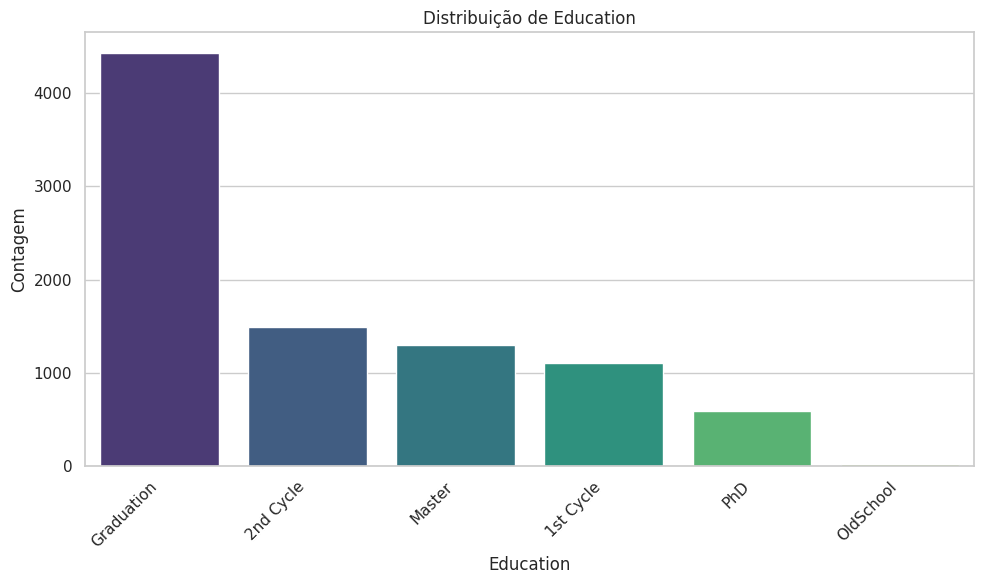

,education,Count
0,Graduation,4429
1,2nd Cycle,1496
2,Master,1303
3,1st Cycle,1104
4,PhD,593
5,OldSchool,26


In [19]:
print(f"\n--- Análise da Coluna: 'education' ---")
print("Valores Únicos:", df['education'].unique())

# Contar a frequência de cada valor
col_counts = df['education'].value_counts().reset_index()
col_counts.columns = ['education', 'Count']

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='education', y='Count', data=col_counts, palette='viridis', hue='education', legend=False)
plt.title('Distribuição de Education')
plt.xlabel('Education')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(col_counts)

In [20]:
moda_education = df['education'].mode()[0]
print(moda_education)
df['education'] = df['education'].fillna(moda_education)

Graduation


In [21]:
df.isnull().sum()[df.isnull().sum()>0]

,0
status,177


In [22]:
num_rows_with_null = df.isnull().any(axis=1).sum()
print(f"Número de linhas com missing values: {num_rows_with_null}")

dataframe_length = len(df)
print(f"Comprimento do df: {dataframe_length}")

percentage_missing = (num_rows_with_null / dataframe_length)

print(f"Percentagem de linhas a excluir (com algum valor a null): {percentage_missing:.2%}")

Número de linhas com missing values: 177
Comprimento do df: 8998
Percentagem de linhas a excluir (com algum valor a null): 1.97%



--- Análise da Coluna: 'status' ---
Valores Únicos: ['Together' 'Divorced' 'Married' nan 'Single' 'Widow' 'Whatever']


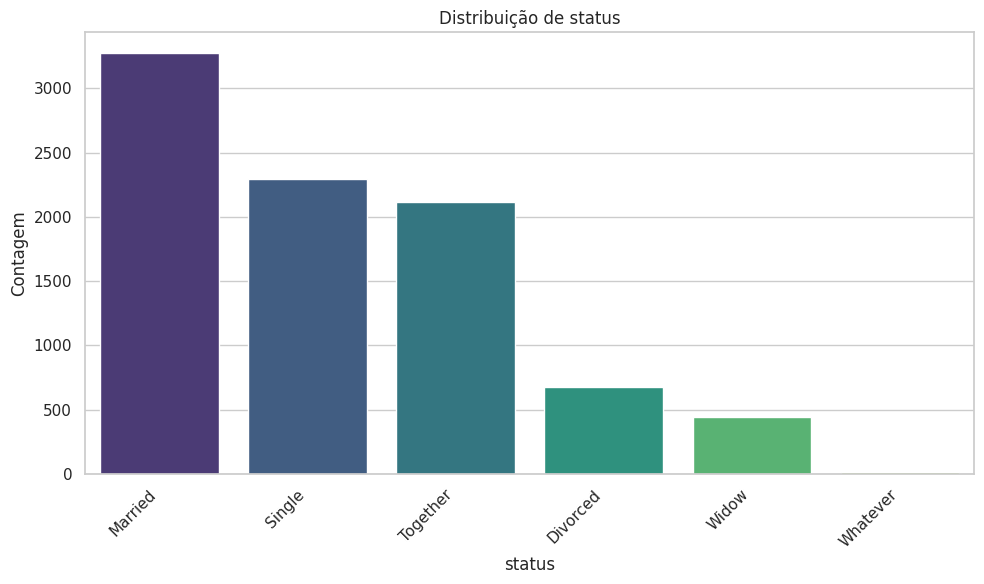

,status,Count
0,Married,3273
1,Single,2293
2,Together,2118
3,Divorced,677
4,Widow,445
5,Whatever,15


In [23]:
print(f"\n--- Análise da Coluna: 'status' ---")
print("Valores Únicos:", df['status'].unique())

# Contar a frequência de cada valor
col_counts = df['status'].value_counts().reset_index()
col_counts.columns = ['status', 'Count']

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='status', y='Count', data=col_counts, palette='viridis', hue='status', legend=False)
plt.title('Distribuição de status')
plt.xlabel('status')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(col_counts)


--- Análise da Coluna: 'status' após tratamento de 'Whatever' ---
Valores Únicos: ['Together' 'Divorced' 'Married' nan 'Single' 'Widow']


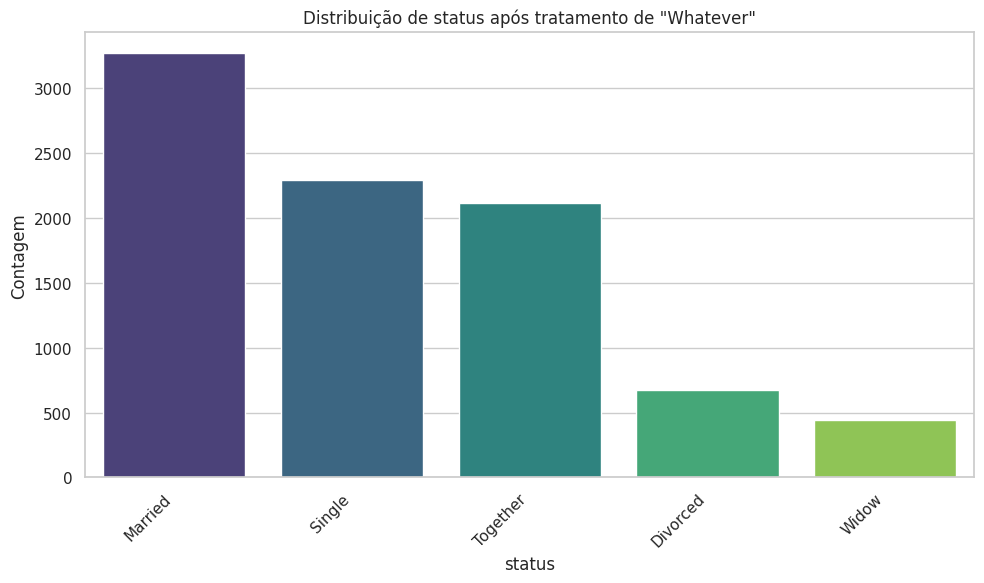

,status,Count
0,Married,3273
1,Single,2293
2,Together,2118
3,Divorced,677
4,Widow,445


In [24]:
df['status'] = df['status'].replace('Whatever', np.nan)

print(f"\n--- Análise da Coluna: 'status' após tratamento de 'Whatever' ---")
print("Valores Únicos:", df['status'].unique())

# Contar a frequência de cada valor
col_counts_updated = df['status'].value_counts().reset_index()
col_counts_updated.columns = ['status', 'Count']

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='status', y='Count', data=col_counts_updated, palette='viridis', hue='status', legend=False)
plt.title('Distribuição de status após tratamento de "Whatever"')
plt.xlabel('status')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(col_counts_updated)

In [25]:
print(f"Comprimento do df ANTES de remover NaN na coluna 'status': {len(df)}")

df.dropna(subset=['status'], inplace=True)

print(f"Comprimento do df DEPOIS de remover NaN na coluna 'status': {len(df)}")
display(df.head())

Comprimento do df ANTES de remover NaN na coluna 'status': 8998
Comprimento do df DEPOIS de remover NaN na coluna 'status': 8806


,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description,current_age_2026
0,1961,90782.0,33,66,1402,37,5,44,10,3,0.0,19,M,Graduation,Together,Take my money!!,65
1,1951,113023.0,32,6,1537,55,1,38,4,2,0.0,9,F,PhD,Divorced,Take my money!!,75
2,2005,28344.0,11,69,44,32,19,24,1,24,1.0,59,M,Graduation,Married,Kind of OK,21
4,1970,91852.0,31,26,1138,59,5,28,4,4,1.0,34,F,Graduation,Together,Take my money!!,56
5,1997,22386.0,14,65,56,47,2,48,2,1,1.0,67,M,PhD,Single,OK nice!,29


In [26]:
df.isnull().sum()[df.isnull().sum()>0]

,0


## Feature Engineering e Sanity Checks ⚙️
Descobrimos que variáveis como `clothes`, `kitchen` ou `toys` são, na verdade, **percentagens** do montante total gasto (`mnt`). Vamos criar novas características preditivas (*Features*):
1.  **Conversão para Valor Absoluto:** Calcular o gasto real em cada categoria.
2.  **Sanity Check:** Somar as percentagens originais para garantir que não existem falhas no registo e que perfazem ~100%.
3.  **Variáveis lógicas:** Criar uma variável binária para os dependentes. (Nota: A `Idade_Atual` já foi criada no Lab 2).

In [27]:
#1. criação de features com valor absoluto
categories = ['clothes', 'kitchen', 'small_appliances', 'toys', 'house_keeping']

for category in categories:
    df[f'{category}_value'] = (df['mnt'] * df[category]) / 100

print("Novas colunas de valor absoluto criadas:")
display(df.head())

Novas colunas de valor absoluto criadas:


,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,...,gender,education,status,description,current_age_2026,clothes_value,kitchen_value,small_appliances_value,toys_value,house_keeping_value
0,1961,90782.0,33,66,1402,37,5,44,10,3,...,M,Graduation,Together,Take my money!!,65,518.74,70.10,616.88,140.20,42.06
1,1951,113023.0,32,6,1537,55,1,38,4,2,...,F,PhD,Divorced,Take my money!!,75,845.35,15.37,584.06,61.48,30.74
2,2005,28344.0,11,69,44,32,19,24,1,24,...,M,Graduation,Married,Kind of OK,21,14.08,8.36,10.56,0.44,10.56
4,1970,91852.0,31,26,1138,59,5,28,4,4,...,F,Graduation,Together,Take my money!!,56,671.42,56.90,318.64,45.52,45.52
5,1997,22386.0,14,65,56,47,2,48,2,1,...,M,PhD,Single,OK nice!,29,26.32,1.12,26.88,1.12,0.56


In [33]:
#2. Sanity Check
df['Soma_Percentagens'] = df[categories].sum(axis=1)
erros_soma = df[(df['Soma_Percentagens'] < 99) | (df['Soma_Percentagens'] > 101)]
print(f"-> Atenção: Encontras {len(erros_soma)} linhas onde as percentagens são diferentes de 100%")

-> Atenção: Encontras 0 linhas onde as percentagens são diferentes de 100%


## Tratamento de *Outliers* 📦
No final da nossa Análise Exploratória (Sessão 2), o *Boxplot* revelou alguns valores atípicos no Montante Gasto (`mnt`).

Para evitar que modelos preditivos aprendam padrões enviesados, vamos aplicar o método de **Winsorization**: limitar (ou "cortar") os valores extremos usando os limites da regra do *Interquartile Range* (IQR), suavizando o ruído sem apagar a linha de dados.

In [35]:

def limitar_outliers(dataset, coluna):

  #Calcular o Q1, Q3, IQR
  Q1 = dataset[coluna].quantile(0.25)
  Q3 = dataset[coluna].quantile(0.75)
  IQR = Q3-Q1

  #Definir limites (thresholds)
  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  #Aplicar os limites para remover os outliers
  dataset[coluna] = np.clip(dataset[coluna], limite_inferior, limite_superior)
  return dataset

df = limitar_outliers(df, 'mnt')


## Transformação de Variáveis Ordinais 🔢
Os modelos matemáticos não "entendem" texto. Temos de transformar variáveis textuais que possuam uma **ordem lógica** em números (pesos).
*   **Education:** A escolaridade tem uma ordem lógica (1st Cycle, Graduation, Master, etc).
*   **Variável Alvo (Description):** Identificámos que esta coluna classifica os clientes por ordem de rentabilidade ("Horrible" < "Meh..." < "Take my money!!").

In [43]:
mapa_educacao = {
'OldSchool': 0,
'1st Cycle': 1,
'2nd Cycle': 2,
'Graduation': 3,
'Master': 4,
'PhD': 5
}

df['education_encoded'] = df['education'].map(mapa_educacao)

mapa_description = {
'Horrible': 1,
'Meh...': 2,
'Kind of OK': 3,
'OK nice!': 4,
'Take my money!!': 5
}

df['description_encoded'] = df['description'].map(mapa_description)









In [44]:
df.head(20)

,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,...,description,current_age_2026,clothes_value,kitchen_value,small_appliances_value,toys_value,house_keeping_value,Soma_Percentagens,education_encoded,description_encoded
0,1961,90782.0,33,66,1402.0,37,5,44,10,3,...,Take my money!!,65,518.74,70.10,616.88,140.20,42.06,99,3,5
1,1951,113023.0,32,6,1537.0,55,1,38,4,2,...,Take my money!!,75,845.35,15.37,584.06,61.48,30.74,100,5,5
2,2005,28344.0,11,69,44.0,32,19,24,1,24,...,Kind of OK,21,14.08,8.36,10.56,0.44,10.56,100,3,3
4,1970,91852.0,31,26,1138.0,59,5,28,4,4,...,Take my money!!,56,671.42,56.90,318.64,45.52,45.52,100,3,5
5,1997,22386.0,14,65,56.0,47,2,48,2,1,...,OK nice!,29,26.32,1.12,26.88,1.12,0.56,100,5,4
6,1984,69485.0,18,73,345.0,71,7,13,1,8,...,OK nice!,42,244.95,24.15,44.85,3.45,27.60,100,3,4
7,1975,68602.0,5,44,41.0,84,1,12,2,0,...,Horrible,51,34.44,0.41,4.92,0.82,0.00,99,3,1
8,1955,109499.0,30,75,1401.0,38,9,35,9,9,...,OK nice!,71,532.38,126.09,490.35,126.09,126.09,100,3,4
9,2009,23846.0,8,153,19.0,18,55,17,10,1,...,Meh...,17,3.42,10.45,3.23,1.90,0.19,101,1,2
10,1964,97492.0,20,93,774.0,37,16,33,9,5,...,OK nice!,62,286.38,123.84,255.42,69.66,38.70,100,4,4


In [41]:
df['description'].unique()

array(['Take my money!!', 'Kind of OK', 'OK nice!', 'Horrible', 'Meh...'],
      dtype=object)

## One-Hot Encoding para Variáveis Nominais 🔀
Para categorias sem ordem matemática (ex: `gender` e `status`), a conversão em "pesos" numéricos geraria ruído (o modelo acharia que "Casado" vale matematicamente mais que "Solteiro").

> Nota: Vamos usar a técnica de **One-Hot Encoding** para criar colunas binárias (Variáveis *Dummy*). Utilizamos `drop_first=True` para evitar o temido problema da *Multicolinearidade* que falámos na teoria.

In [45]:
# Criar Dummies para o Género e Estado Civil
df = pd.get_dummies(df, columns=['gender', 'status'], drop_first=True, dtype=int)

print("Algumas das novas colunas criadas:")
print([col for col in df.columns if 'gender_' in col or 'status_' in col])


Algumas das novas colunas criadas:
['gender_M', 'status_Married', 'status_Single', 'status_Together', 'status_Widow']


In [47]:
df.head(15)

,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,...,toys_value,house_keeping_value,Soma_Percentagens,education_encoded,description_encoded,gender_M,status_Married,status_Single,status_Together,status_Widow
0,1961,90782.0,33,66,1402.0,37,5,44,10,3,...,140.20,42.06,99,3,5,1,0,0,1,0
1,1951,113023.0,32,6,1537.0,55,1,38,4,2,...,61.48,30.74,100,5,5,0,0,0,0,0
2,2005,28344.0,11,69,44.0,32,19,24,1,24,...,0.44,10.56,100,3,3,1,1,0,0,0
4,1970,91852.0,31,26,1138.0,59,5,28,4,4,...,45.52,45.52,100,3,5,0,0,0,1,0
5,1997,22386.0,14,65,56.0,47,2,48,2,1,...,1.12,0.56,100,5,4,1,0,1,0,0
6,1984,69485.0,18,73,345.0,71,7,13,1,8,...,3.45,27.60,100,3,4,1,0,0,1,0
7,1975,68602.0,5,44,41.0,84,1,12,2,0,...,0.82,0.00,99,3,1,1,0,0,1,0
8,1955,109499.0,30,75,1401.0,38,9,35,9,9,...,126.09,126.09,100,3,4,1,0,0,0,0
9,2009,23846.0,8,153,19.0,18,55,17,10,1,...,1.90,0.19,101,1,2,0,0,0,1,0
10,1964,97492.0,20,93,774.0,37,16,33,9,5,...,69.66,38.70,100,4,4,1,0,1,0,0


## Normalização de Escalas (*Scaling*) ⚖️
Colunas como `income` rondam nos milhares, enquanto a frequência (`frq`) rondam nas dezenas. Modelos baseados na distância (como o KNN) dariam importância excessiva ao rendimento apenas por causa da sua grandeza matemática.

Vamos usar o **StandardScaler** para colocar as características preditivas contínuas na mesma métrica (Média 0 e Desvio Padrão 1).


In [ ]:
# Variáveis numéricas que precisam de standardização
colunas_para_escalar = [
    'income', 'current_age_2026', 'rcn', 'mnt', 'frq',
    'Valor_Clothes', 'Valor_Kitchen', 'Valor_Small_appliances',
    'Valor_Toys', 'Valor_House_keeping'
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#Ajustar (fit) e transformar os dados
df[colunas_para_escalar] = scaler.fit_transform(df[colunas_para_escalar])

## Preparação Final e Train/Test Split ✂️
O passo final desta fase:
1.  Remover colunas originais inúteis ou já processadas.
2.  Isolar a matriz de *Features* (`X`) do vetor Alvo (`y`).
3.  Dividir os dados em **Treino (80%)** e **Teste (20%)**.

> Importante: Como queremos prever a segmentação do cliente, o parâmetro `stratify=y` obriga a que a proporção dos vários perfis seja equitativa tanto no grupo de teste como de treino.

In [55]:
from sklearn.model_selection import  train_test_split

# 1. Remover colunas desnecessárias
colunas_remover = ['age', 'education', 'description', 'Soma_Percentagens'] + categories
df_final = df.drop(columns=colunas_remover)

# 2. X e y
X = df_final.drop(columns=['description_encoded'])
y = df_final['description_encoded']

# Proteção final contra nulos remanescentes
X = X.fillna(0)
y = y.fillna(y.mode())

# Importar train_test_split
from sklearn.model_selection import train_test_split

# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Modelo pronto para a Sessão 4!")
print(f"Treino -> Features: {X_train.shape}, Target: {y_train.shape}")
print(f"Teste  -> Features: {X_test.shape}, Target: {y_test.shape}")

# Opcional: exportar para CSV
# X_train.to_csv('X_train.csv', index=False)


Modelo pronto para a Sessão 4!
Treino -> Features: (7044, 18), Target: (7044,)
Teste  -> Features: (1762, 18), Target: (1762,)
